In [468]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

import mdtraj as md
import os, sys
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
from functools import reduce, partial
import scipy
from typing import Tuple
from importlib import reload
from cycler import cycler
from itertools import chain
# source modules and classes being developed 
from writhe_tools.writhe import (Writhe,
                                 get_segments)


from writhe_tools.plots import (
                                proj2d,
                                fes2d,
                                get_color_list,
                                box_plot,
                                build_matrix_boxplot_grid,
                                lineplot1D)

from writhe_tools.tcca import CCA, tCCA

from matplotlib.lines import Line2D

from writhe_tools.stats import Kmeans, rotate_points, acf, pmf, corr, window_average


from writhe_tools.md_tools import (ResidueDistances,
                                   get_residues,
                                   calc_sa,
                                   traj_slice,
                                   load_traj,
                                   plot_distance_matrix,
                                   residue_distances,                                 
                                   to_contacts
                                    )


from writhe_tools.utils import (lsdir,
                                group_by,
                                reindex_list,
                                contiguous_bool,
                                to_numpy,
                                num_str,
                                load_dict,
                                save_dict,
                                product
                                )


from typing import Dict, List, Tuple


import warnings
warnings.filterwarnings("ignore")



fes2d_args = dict(
      cmap="coolwarm",
      bins=55,
      n_contours=8,
      contour_lines=True,
      alpha_lines=0.35,
      alpha_contours=0.6,
      mask=False,
      scatter=True,
      scatter_alpha = .15,
      scatter_size=.05,
      scatter_stride=50,
      scatter_max=.35,
      scatter_min=.15,
      scatter_cmap="coolwarm",
      hide_ax=False,
      extend_border=0.1,
    )



def fill_1d(x, values, indices):
    x[indices] = values
    return x

def fill(x, index, val):
    x[:, index] = val
    return x

def prod(vectors, sum_=False):
    if sum_:
        vectors = [v.sum(axis=-1) for v in vectors]
    return reduce(np.multiply, vectors)

split = partial(np.array_split, indices_or_sections=2, axis=-1) 

ternary_bool = lambda distances : prod([to_contacts(i, 1).any(1) for i in split(distances)])

isin_index = lambda x, y : np.where(np.isin(x, y))[0]




def bootstrap(data: np.ndarray,
              confidence_level: float = 0.68,
              n_resamples: int = 500,
              lower_upper: bool = False,
              method: str = "percentile",
              statistic: callable=np.mean) -> Tuple[float, float]:
    """
    Bootstrap binary data to get the mean and an intentionally wide error estimate.

    Parameters:
        data: binary array of 0s and 1s
        confidence_level: typically 0.99 for wider intervals
        n_resamples: lower values increase variability (default 500)
        method: use 'percentile' to produce wider CIs

    Returns:
        mean: estimated mean of the binary array
        error: half-width of the confidence interval
    """

    res = scipy.stats.bootstrap((data,), statistic=statistic,
                    confidence_level=confidence_level,
                    n_resamples=n_resamples,
                    method=method,
                    random_state=0)

    mean = np.mean(data) if data.ndim == 1 else data.mean(0)
    error = [res.confidence_interval.low, res.confidence_interval.high] if lower_upper\
            else (res.confidence_interval.high - res.confidence_interval.low) / 2
    if data.ndim > 1:error = np.stack(error)
    
    return mean, error


from pyblock.blocking import reblock, find_optimal_block
from collections import Counter
def block_error(x: np.ndarray, lower_upper: bool = False, weights: np.ndarray=None):
    """
    x : (N, d) numpy array with d features and N measurements
    """
    n = x.shape[0]
    blocks = reblock(x.T, weights=weights)
    optimal_indices = np.asarray(find_optimal_block(n, blocks))
    isnan = np.isnan(optimal_indices)
    #mode = Counter(optimal_indices[~isnan].astype(int)).most_common()[0][0]
    optimal_indices[isnan] = -1 # biggest block
    optimal_indices=optimal_indices.astype(int)
    #op
    #print(optimal_indices[0])
    if x.ndim == 1:
        mu = np.sum(x * weights) if weights is not None else x.mean()
        return lu_from_error(x.mean(), blocks[optimal_indices[0]].std_err.item()) if lower_upper else\
                (x.mean(), blocks[optimal_indices[0]].std_err.item())
    else:
        mu = np.sum(x * weights[:, None], 0) if weights is not None else x.mean(0)
        return lu_from_error(mu, np.asarray([blocks[i].std_err[j] for j, i in enumerate(optimal_indices.astype(int))]))\
                if lower_upper else (mu, np.asarray([blocks[i].std_err[j] for j, i in enumerate(optimal_indices.astype(int))]))

def lu_from_error(mean, error):
    if all(isinstance(i, (float, int)) for i in (mean, error)):
        mean, error = [mean], [error]
    return mean, np.array([[mu - err, mu + err] for mu, err in zip(mean, error)]).T

# convenience (hard coded to 2 monomers) function to combine stats and prop error for averages to be taken over both monomers
def monomer_aggr_stats(x, 
                       error:callable=block_error, 
                       lower_upper: bool = False, 
                       fill_bool:np.ndarray=None):
    # compue mean and error over both monomers, aggregate, fill zeros for plotting, give lower, upper errors or absolute error
    ave, err = error(x, lower_upper=False)
    ave = np.add.reduce(split(x.mean(0))) / 2
    err = np.linalg.norm(err.reshape(2, -1), axis=0) / 2
    
    if lower_upper:
        # very simple error propogation here (arguably too simple)
        err = lu_from_error(ave, err)[-1]                   
        if fill_bool is not None:
            ave = fill_1d(np.zeros(len(fill_bool)), ave, fill_bool)
            err = np.stack([fill_1d(np.zeros(len(fill_bool)), i, fill_bool) for i in err])

        return ave, err


    return (ave, err) if fill_bool is None else [fill_1d(np.zeros(len(fill_bool)), i, fill_bool) for i in [ave, err]]


#block_error(np.arange(10000), lower_upper=False)
path = "/data/r1r2"
epi_dir = f"{path}/epi002"
apo_dir = f"{path}/apo"
cam_dir = f"{path}/cam1"
paths = [apo_dir, epi_dir, cam_dir]
labels = ['APO', 'EPI-002', '1aa']

protein_files = ['/data/r1r2/apo/protein.100us.dcd',
                 '/data/r1r2/epi002/protein.100us.dcd',
                 '/data/r1r2/cam1/protein.85us.dcd']


ligand_files = [lsdir(i, keyword=['dcd', 'ligand'], exclude=['wrap'], match=all)[0] for i in paths[1:]]
protein_pdb = '/data/r1r2/epi002/R2_dimer.pdb'
ligand_pdbs = [
               '/data/r1r2/epi002/R2_dimer.epi002.rename.pdb',
               '/data/r1r2/cam1/protein.ligand.pdb',
               ]
helix_pdb = '/data/r1r2/monomer_r1r2_helix.pdb'

trunc = .3
pre_trunc = .3
state_width = .8
state_font_scale = 1.5
codes = np.array(list(md.load(protein_pdb).top.to_fasta()[0]))[:24]


r2 = 'MEVQLGLGRVYPRPPSKTYRGAFQNLFQSVREVIQNPGPRHPEAASAAPPGASLLLLQQQQQQQQQQQQQQQQQQQQQETSPRQQQQQQGEDGSPQAHRRGPTGYLVLDEEQQPSQPQSALECHPERGCVPEPGAAVAASKGLPQQLPAPPDEDDSAAPSTLSLLGPTFPGLSSCSADLKDILSEASTMQLLQQQQQEAVSEGSSSGRAREASGAPTSSKDNYLGGTSTISDNAKELCKAVSVSMGLGVEALEHLSPGEQLRGDCMYAPLLGVPPAVRPTPCAPLAECKGSLLDDSAGKSTEDTAEYSPFKGGYTKGLEGESLGCSGSAAAGSSGTLELPSTLSLYKSGALDEAAAYQSRDYYNFPLALAGPPPPPPPPHPHARIKLENPLDYGSAWAAAAAQCRYGDLASLHGAGAAGPGSGSPSAAASSSWHTLFTAEEGQLYGPCGGGGGGGGGGGGGGGGGGGGGGGGEAGAVAPYGYTRPPQGLAGQESDFTAPDVWYPGGMVSRVPYPSPTCVKSEMGPWMDSYSGPYGDMRLETARDHVLPIDYYFPPQKT'[390:414]
xticks = [f'{i}{j}' for i, j in zip(codes, 
                                    np.arange(391, 415)) ]


# Computations

In [175]:
# protein only calculations
label = 'APO'
ca_selection = md.load(protein_pdb).top.select('name CA')
sequence, ca_index = get_residues(md.load(protein_pdb))
# 1 letter codes for the monomer sequence (just 1)
codes = np.array(list(md.load(protein_pdb).top.to_fasta()[0]))[:24]

unitcell_lengths = md.load(protein_files[0], top=protein_pdb).unitcell_lengths


ca_distances = ResidueDistances(index_0=np.arange(24),
                                index_1=np.arange(24, 48),
                                traj=md.load(protein_files[0], top=protein_pdb, atom_indices=ca_selection)
                               )

# dimer events from ca_distances
dimer = ca_distances.contacts(1).any(1)
dimer_events = contiguous_bool(bools=dimer)
dimer_lengths = 0.24 * np.fromiter(map(len, dimer_events), float) # scale by physical time

# sort by event length
sort = dimer_lengths.argsort()[::-1]
dimer_events = reindex_list(dimer_events, sort)
dimer_lengths = dimer_lengths[sort]

# # structural features
# sa = np.stack([calc_sa(md.load(protein_files[0], top=protein_pdb, atom_indices=j), helix_pdb) for j in split(ca_selection)])

dssp = np.where(md.compute_dssp(traj=md.load(protein_files[0], top=protein_pdb)) == 'H', 1, 0)[:, ca_index].reshape(-1, 2, 24
                                                                                                                   ).transpose(1, 0, 2)

# writhe = Writhe(xyz=md.load(protein_files[0], top=protein_pdb, atom_indices=ca_selection).xyz)
# segments = np.concatenate([get_segments(index0=np.arange(24)),
#                            get_segments(index0=np.arange(24, 48)),
#                            get_segments(index0=np.arange(24), index1=np.arange(24, 48))
#                           ])

# writhe_features = writhe.compute_writhe(segments=segments,
#                                         cuda=True,
#                                         store_results=False,
#                                         lengths=unitcell_lengths,
#                                         )['writhe_features']
# # dimensionality reduction (don't use this if you don't have truly continuous data
# tcca = tCCA(writhe_features, lag=10, dim=10,).fit()

# # for non-continuous data (replica exchange, metaD, etc, ..) for PCA (or whatever else you want)

# # compute the projection and then align to a reference because eigen vects might have flipped sign
# proj = tcca.transform(writhe_features); proj = rotate_points(np.load(lsdir(paths[0], keyword='writhe_tcca_lag_')[0])[1:, :2],
#                                                              proj, so3=False)

# # to cluster with Kmeans
# # dtraj, frames_cl = Kmeans(proj, n_clusters=7, n_dim=2)

# # Kmeans isn't deterministic, so we use a pre computed clustering to keep consistency with reported values

# ## WARNING - MUST HAVE REFERNECE AVAILABLE FOR THIS TO WORK - CAN JUST COMMENT THIS OUT AND RECLUSTER USING LINES ABOVE
# dtraj = load_dict('density_clusters.pkl')[0]; frames_cl = group_by(dtraj)
# centroids = group_by(dtraj, proj, reduction = partial(np.mean, axis = 0))


In [259]:
import pandas as pd
import numpy as np



# shifts of 'vanilla' tau* and covalently linked tau* ---- not used
exp_protein_covalent = pd.DataFrame(data = [
    [8.22172, 119.95584, 8.21271, 119.85075, 0.022867803],
    [8.02489, 119.96152, 8.01727, 119.94535, 0.008277871],
    [8.08397, 121.21365, 8.08512, 121.19888, 0.003169955],
    [8.45784, 109.75427, 8.45535, 109.52636, 0.04564996],
    [8.2248, 116.16223, 8.22489, 116.22847, 0.013248306],
    [8.5496, 125.94403, 8.53315, 125.97475, 0.017559933],
    [8.17713, 120.05744, 8.2042, 120.02551, 0.027813053],
    [7.94541, 124.03962, 7.95758, 123.69739, 0.069519521],
    [8.01772, 122.12372, 8.00571, 121.90888, 0.044614898],
    [7.98861, 121.9914, 7.9626, 121.88024, 0.034216691],
    [8.11103, 122.28622, 0.0, 0.0, 0.0],
    [7.99391, 121.68358, 7.96666, 121.48314, 0.048472778],
    [8.08023, 118.11224, 8.04415, 117.92045, 0.052660256],
    [8.19376, 116.15629, 8.1571, 115.94294, 0.056255529],
    [8.21013, 122.33612, 8.18072, 122.14297, 0.048551262],
    [8.22172, 119.95584, 8.20607, 119.64615, 0.06388457],
    [8.27757, 110.10479, 8.24997, 109.87235, 0.054063797],
    [8.2631, 120.74169, 8.26222, 120.69977, 0.008430057],
    [8.32107, 122.73478, 8.31135, 122.69118, 0.013058208],
    [8.30772, 123.2969, 8.30191, 123.14677, 0.030582949],
    [8.11841, 113.96859, 8.10193, 113.86075, 0.02714349],
    [8.08198, 123.44984, 8.05434, 123.34132, 0.035143039],
    [8.20895, 118.90971, 8.20067, 118.7105, 0.040693284],
    [8.32586, 109.93328, 8.31012, 109.82356, 0.027005309],], 
    columns = ["H_ppm","N_ppm","H_ppm","N_ppm","CSP",],
    index=range(391, 391 + 24))



# shifts of tau* 'fragments' with epi and 'half-labled' tau* 'fragments' with epi (no covalent link)
exp_monomer_ligand = pd.DataFrame(data = np.array([
    [8.21129, 119.92753, 8.21047, 119.91165, 0.003280149],
    [8.01715, 119.96458, 8.01518, 119.95751, 0.002424932],
    [8.08263, 121.20818, 8.08670, 121.21876, 0.004587195],
    [8.45399, 109.64446, 8.45471, 109.59827, 0.009266016],
    [8.22419, 116.19810, 8.22605, 116.20928, 0.002908487],
    [8.53323, 125.93933, 8.52859, 125.94423, 0.004742362],
    [8.18127, 120.02207, 8.18938, 120.01448, 0.008250844],
    [7.94008, 123.80474, 7.94142, 123.74317, 0.012386694],
    [7.98651, 121.94307, 7.99081, 121.88797, 0.011829218],
    [7.96500, 121.94425, 7.95682, 121.92491, 0.009048416],
    [8.11441, 122.06159, 8.11712, 122.03310, 0.006309620],
    [7.94908, 121.25258, 7.94105, 121.18560, 0.015618378],
    [8.00797, 117.77708, 8.00094, 117.74614, 0.009365482],
    [8.12474, 119.47333, 8.11615, 119.40681, 0.015836177],
    [8.29653, 122.92548, 8.29476, 122.88788, 0.007725497],
    [8.32334, 120.64172, 8.32570, 120.62569, 0.003980959],
    [8.35699, 110.19628, 8.35214, 110.14727, 0.010936256],
    [8.24647, 120.67401, 8.24421, 120.66329, 0.003115178],
    [8.30841, 122.74126, 8.30660, 122.73088, 0.002754247],
    [8.30324, 123.20672, 8.30244, 123.18975, 0.003487010],
    [8.10412, 113.90649, 8.10236, 113.88892, 0.003930114],
    [8.06487, 123.38528, 8.06086, 123.37257, 0.004747827],
    [8.20408, 118.82542, 8.20233, 118.79492, 0.006346062],
    [8.31866, 109.88336, 8.31709, 109.86280, 0.004401527],
    ], dtype=float),
    columns = ["H_ppm","N_ppm","H_ppm","N_ppm","CSP",],
    index=range(391, 391 + 24))



# shifts of covalently linked tau* and covalently linked tau* with EPI --- not used
exp_dimer_ligand = pd.DataFrame(data = [
    [8.21271, 119.85075, 8.21245, 119.82219, 0.005717914],
    [8.01727, 119.94535, 8.01866, 119.94156, 0.001583245],
    [8.08512, 121.19888, 8.08254, 121.17861, 0.004805342],
    [8.45535, 109.52636, 8.45675, 109.44936, 0.015463505],
    [8.22489, 116.22847, 8.22248, 116.26586, 0.007856754],
    [8.53315, 125.97475, 8.53301, 125.98917, 0.002887396],
    [8.2042, 120.02551, 8.20712, 120.027, 0.002935167],
    [7.95758, 123.69739, 7.96331, 123.55788, 0.028484285],
    [8.00571, 121.90888, 8.00262, 121.83685, 0.014733667],
    [7.9626, 121.88024, 7.95642, 121.85155, 0.008433092],
    [0.0, 0.0, 0.0, 0.0, 0.0],
    [7.96666, 121.48314, 7.96296, 121.44349, 0.008750709],
    [8.04415, 117.92045, 8.03385, 117.8467, 0.017990345],
    [8.1571, 115.94294, 8.144, 115.89795, 0.015892577],
    [8.18072, 122.14297, 8.16908, 122.13656, 0.011710385],
    [8.20607, 119.64615, 8.20101, 119.58317, 0.013574344],
    [8.24997, 109.87235, 8.24674, 109.82669, 0.009686399],
    [8.26222, 120.69977, 8.26245, 120.69404, 0.001168852],
    [8.31135, 122.69118, 8.30963, 122.69268, 0.001745967],
    [8.30191, 123.14677, 8.3006, 123.1115, 0.007174609],
    [8.10193, 113.86075, 8.09867, 113.84319, 0.004791841],
    [8.05434, 123.34132, 8.04659, 123.29566, 0.011977309],
    [8.20067, 118.7105, 8.19904, 118.66118, 0.00999777],
    [8.31012, 109.82356, 8.31135, 109.79238, 0.006356146],],
     columns = ["H_ppm","N_ppm","H_ppm","N_ppm","CSP",],
     index=range(391, 391 + 24))

# shifts of tau* 'fragments' and 'half-labled' tau* 'fragments' (no covalent link)
exp_protein_apo = pd.DataFrame(
       [[8.21285, 119.93543, 8.21193, 119.92601, 0.00209663],
        [8.01795, 119.96388, 8.01599, 119.96198, 0.001996497],
        [8.08301, 121.2056, 8.0855, 121.21075, 0.002694624],
        [8.45315, 109.67229, 8.45529, 109.63096, 0.008538522],
        [8.22503, 116.19943, 8.22296, 116.19369, 0.002367024],
        [8.53427, 125.93723, 8.53208, 125.92749, 0.002931007],
        [8.17953, 120.02492, 8.18506, 120.01678, 0.005764658],
        [7.939, 123.83912, 7.94183, 123.7726, 0.013601666],
        [7.98688, 121.95945, 7.98775, 121.92615, 0.006716584],
        [7.9678, 121.95667, 7.96747, 121.93249, 0.004847246],
        [8.11338, 122.09819, 8.11491, 122.07049, 0.005747391],
        [7.95126, 121.28189, 7.94642, 121.24136, 0.009441019],
        [8.01318, 117.80453, 8.00585, 117.76133, 0.011330424],
        [8.12906, 119.5005, 8.12158, 119.44926, 0.01268747],
        [8.30015, 122.93005, 8.29513, 122.90241, 0.007467207],
        [8.32447, 120.65495, 8.32442, 120.63085, 0.004820259],
        [8.35881, 110.21205, 8.35505, 110.17773, 0.007826372],
        [8.24806, 120.67842, 8.24706, 120.67288, 0.001492536],
        [8.30994, 122.73837, 8.30814, 122.73708, 0.001818396],
        [8.30412, 123.22166, 8.30381, 123.20325, 0.003695027],
        [8.10515, 113.92247, 8.10384, 113.90837, 0.003109421],
        [8.06741, 123.39938, 8.06502, 123.38755, 0.003363043],
        [8.20561, 118.83735, 8.20488, 118.80878, 0.005760442],
        [8.31994, 109.89528, 8.31818, 109.87463, 0.004489376],
    ],
    columns=[
        "H_ppm_1",
        "N_ppm_1",
        "H_ppm_2",
        "N_ppm_2",
        "CSP",
    ],
)



exp = {'dimer_protein' : exp_protein_covalent, 
       'monomer_ligand' : exp_monomer_ligand,
       'dimer_ligand' : exp_dimer_ligand,
       'monomer_protein' : exp_protein_apo
      }


def pyblock_function_error(data, func, var_names=None):
    """
    Reblocking-based propagated error for a scalar function of the mean of a
    serially correlated multivariate time series.

    This computes:
        value = f(mean(x0), mean(x1), ..., mean(x_{d-1}))
    and estimates its blocked standard error via
        var_f ≈ grad^T Cov(mean_vector) grad
    using joint reblocking across all variables.

    Parameters
    ----------
    data : array-like, shape (n, d) or (n,)
        Serially correlated samples. Each row is one time point / observation.
    func : str or sympy expression
        Scalar function of the variables. By default the variables are named
        x0, x1, ..., x{d-1}. Example:
            "sqrt((x0-x1)**2 + (a*(x2-x3))**2)"
        If you want extra symbols like 'a', substitute them numerically before
        passing the expression, e.g.
            func = sympy.sqrt((x0-x1)**2 + (2.0*(x2-x3))**2)
    var_names : list of str, optional
        Variable names corresponding to the d columns of `data`.
        If None, uses x0, x1, ..., x{d-1}.

    Returns
    -------
    mean_value : float
        f evaluated at the overall mean vector, using the optimal block.
    blocked_error : float
        Blocked propagated standard error. Returns np.nan if no optimal block
        is found by the pyblock criterion.
    details : dict
        Extra information, including:
            - optimal_block
            - optimal_block_size
            - n_blocks_used
            - mean_vector
            - gradient_at_mean
            - sympy_function
            - sympy_gradient
            - history  (all reblocking levels)

    Notes
    -----
    - This computes f(E[X]), not E[f(X)].
    - Reblocking is done jointly across all columns.
    - The optimal-block rule matches pyblock's current logic:
          B3 > 2 * n0 * (SE(B)/SE(0))**4
      scanned backward over reblocking levels.
    """
    import numpy as np
    import sympy as sp

    data = np.asarray(data, dtype=float)
    if data.ndim == 1:
        data = data[:, None]
    if data.ndim != 2:
        raise ValueError("data must have shape (n, d) or (n,)")

    n0, d = data.shape
    if n0 < 2:
        raise ValueError("Need at least 2 samples for reblocking.")

    # Build symbols
    if var_names is None:
        symbols = sp.symbols(f"x0:{d}", real=True)
    else:
        if len(var_names) != d:
            raise ValueError("len(var_names) must equal data.shape[1]")
        symbols = sp.symbols(list(var_names), real=True)

    symbol_map = {str(s): s for s in symbols}

    # Parse scalar sympy expression
    f_sym = sp.sympify(func, locals=symbol_map)
    if not f_sym.free_symbols.issubset(set(symbols)):
        raise ValueError(
            "func contains symbols not present in the data columns. "
            "Use var_names or substitute constants numerically first."
        )

    grad_sym = [sp.diff(f_sym, s) for s in symbols]

    # Lambdify scalar function and analytic gradient
    f_num = sp.lambdify(symbols, f_sym, modules="numpy")
    grad_num = sp.lambdify(symbols, grad_sym, modules="numpy")

    history = []
    current = data.copy()
    iblock = 0

    while current.shape[0] >= 2:
        ndata = current.shape[0]
        mean_vec = current.mean(axis=0)

        # Covariance across the current reblocked samples (which are block means)
        cov_blocks = np.atleast_2d(np.cov(current, rowvar=False, ddof=1))

        # Covariance of the estimator of the overall mean vector
        cov_mean = cov_blocks / ndata

        grad = np.asarray(grad_num(*mean_vec), dtype=float).reshape(-1)
        if grad.size != d:
            raise ValueError("Analytic gradient does not have length d.")

        mean_value = float(np.asarray(f_num(*mean_vec), dtype=float).reshape(()))

        var_f = float(grad @ cov_mean @ grad)
        if var_f < 0.0 and abs(var_f) < 1e-14:
            var_f = 0.0

        std_err = np.sqrt(var_f) if var_f >= 0.0 else np.nan
        std_err_err = std_err / np.sqrt(2.0 * (ndata - 1)) if ndata > 1 else np.nan

        history.append(
            {
                "block": iblock,
                "block_size": 2 ** iblock,
                "ndata": ndata,
                "mean_vector": mean_vec.copy(),
                "cov_blocks": cov_blocks.copy(),
                "cov_mean": cov_mean.copy(),
                "gradient": grad.copy(),
                "mean": mean_value,
                "std_err": std_err,
                "std_err_err": std_err_err,
            }
        )

        # pyblock-style pairwise reblocking:
        # discard last sample if odd, then average neighboring pairs
        if ndata % 2 == 1:
            current = current[:-1]

        if current.shape[0] < 2:
            break

        current = 0.5 * (current[0::2] + current[1::2])
        iblock += 1

    if len(history) == 0:
        raise RuntimeError("No reblocking levels were generated.")

    # pyblock-style optimal block search
    # source logic: scan backward and keep overwriting when criterion passes
    se0 = history[0]["std_err"]
    optimal_block = float("nan")

    if np.isfinite(se0) and se0 > 0.0:
        for h in reversed(history):
            B3 = 2 ** (3 * h["block"])
            if B3 > 2.0 * n0 * (h["std_err"] / se0) ** 4:
                optimal_block = h["block"]

    if np.isnan(optimal_block):
        mean_value = history[0]["mean"]
        blocked_error = np.nan
        details = {
            "optimal_block": np.nan,
            "optimal_block_size": np.nan,
            "n_blocks_used": np.nan,
            "mean_vector": history[0]["mean_vector"],
            "gradient_at_mean": history[0]["gradient"],
            "sympy_function": f_sym,
            "sympy_gradient": grad_sym,
            "history": history,
        }
        return mean_value, blocked_error, details

    opt = history[int(optimal_block)]
    mean_value = opt["mean"]
    blocked_error = opt["std_err"]
    details = {
        "optimal_block": opt["block"],
        "optimal_block_size": opt["block_size"],
        "n_blocks_used": opt["ndata"],
        "mean_vector": opt["mean_vector"],
        "gradient_at_mean": opt["gradient"],
        "sympy_function": f_sym,
        "sympy_gradient": grad_sym,
        "history": history,
    }

    return mean_value, blocked_error, details

# mean_f, err_f, info = [pyblock_function_error(
#     i,  # shape (n, 4), columns = x0, x1, y0, y1
#     "sqrt((x0 - x2)**2 + (2.0 * (x1 - x3))**2)"
# )[1] for i in inp]
#deleted first and last already


In [24]:
def get_shifts(file):
    keys, values = load_dict(file)[::-1]
    cs, groups = group_by(np.array([num_str(i, reverse=True) for i in keys]), values.T, return_keys=True)
    print(groups)
    return cs

 # protien-protein CSP

In [235]:
def csp(x0,x1, y0,y1):
    return ((x0-x1)**2 + (0.2*(y0-y1)) ** 2) ** 0.5
    
def propagated_error(x0,y0, x1, y1, sx0, sy0, sx1, sy1, a=0.2):
    dx = x0 - x1
    dy = y0 - y1
    f = np.sqrt(dx**2 + (a * dy)**2)

    return np.sqrt(
        dx**2 * (sx0**2 + sx1**2) +
        (a**4) * dy**2 * (sy0**2 + sy1**2)
    ) / f

In [246]:
data = np.stack(get_shifts('apo_cs.pkl')[-2:])[:, :-1].reshape(2, 2, 22, -1).mean(1)


['CA_' 'CB_' 'C_' 'HA_' 'H_' 'N_']


['CA_' 'CB_' 'C_' 'HA_' 'H_' 'N_']
0.6723276060629468


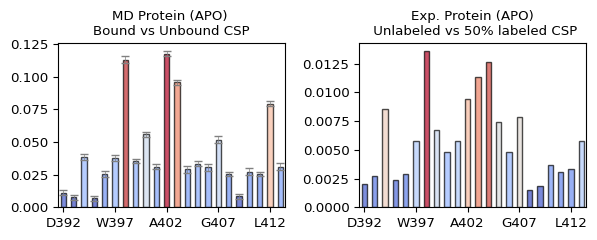

In [324]:
keys, values = load_dict('apo_cs.pkl')[::-1]
hn_comp_mu = np.stack(get_shifts('apo_cs.pkl')[-2:])[:, :-1].reshape(2, 2, 22, -1).mean(1) 
#hn_comp_mu_sep = .5 * (np.stack(get_shifts('apo_cs0.pkl')[-2:])[:, :-1] + np.stack(get_shifts('apo_cs1.pkl')[-2:])[:, :-1])

protein_csp_comp = np.linalg.norm((hn_comp_mu[..., dimer].mean(-1) - 
                   hn_comp_mu[..., ~dimer].mean(-1)) * np.array([1, 0.2]).reshape(2, 1), axis=0)

# disgusting code to propogate error through the CSP function

# hn_comp_mu_err_dimer = [monomer_aggr_stats(i, lower_upper=False) for i in 
#     np.stack(get_shifts('apo_cs.pkl')[-2:])[:, :-1].reshape(2, 44, -1).transpose(0, 2, 1)[:, dimer]]
# hn_comp_mu_err_not_dimer = [monomer_aggr_stats(i, lower_upper=False) for i in 
#     np.stack(get_shifts('apo_cs.pkl')[-2:])[:, :-1].reshape(2, 44, -1).transpose(0, 2, 1)[:, ~dimer]]

err = propagated_error(*np.concatenate([hn_comp_mu[...,dimer].mean(-1),
                                        hn_comp_mu[...,~dimer].mean(-1),
                                        hn_comp_mu[...,dimer].std(-1) / np.sum(dimer) ** .5,
                                        hn_comp_mu[...,~dimer].std(-1) / np.sum(~dimer) ** .5,
                                       ], 0)) * 1.92

where =  exp['monomer_protein']['CSP'].to_numpy()[1:-1] != 0.0

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))
scale = 1.6
box_plot(protein_csp_comp[where],
         ax=axes[0],
         errors=err[where],
         font_scale=scale,
         error_capsize=3,
         width=.5,
         labels=xticks[1:-1],
         #color_list='indianred',
         alpha=.7, 
         color_height=True,
         cmap='coolwarm', 
         title='MD Protein (APO) \nBound vs Unbound CSP',
         label_stride=5)

# box_plot(exp['protein']['diff']['CSP'].to_numpy()[1:-1][where], ax=axes[1],
#          font_scale=scale, width=.5, color_height=True, cmap='coolwarm',
#          alpha=.7, title='Experimental R2 Protein CSP', label_stride=3,
#         )

box_plot(exp['monomer_protein']['CSP'].to_numpy()[1:-1][where],
         ax=axes[1],
         labels=xticks[1:-1],
         font_scale=scale, 
         width=.5, 
         color_height=True,
         cmap='coolwarm',
         alpha=.7,
         title = 'Exp. Protein (APO)\n Unlabeled vs 50% labeled CSP', 
         label_stride=5,)


fig.tight_layout()
print(corr(exp['monomer_protein']['CSP'].to_numpy()[1:-1][where],
           protein_csp_comp[where] 
          )
     )


['CA_' 'CB_' 'C_' 'HA_' 'H_' 'N_']
0.6640569821099382


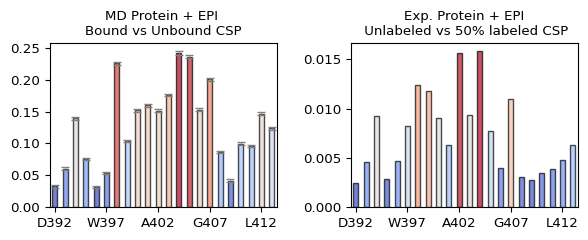

In [328]:
epi_dimer = np.load('./events/epi_dimer.npy')
keys, values = load_dict('epi_cs.pkl')[::-1]
hn_comp_mu = np.stack(get_shifts('epi_cs.pkl')[-2:])[:, :-1].reshape(2, 2, 22, -1).mean(1) 
#hn_comp_mu_sep = .5 * (np.stack(get_shifts('epi_cs0.pkl')[-2:])[:, :-1] + np.stack(get_shifts('epi_cs1.pkl')[-2:])[:, :-1])

protein_csp_comp = np.linalg.norm((hn_comp_mu[..., epi_dimer].mean(-1) - 
                   hn_comp_mu[..., ~epi_dimer].mean(-1)) * np.array([1, 0.2]).reshape(2, 1), axis=0)

where =  exp['monomer_ligand']['CSP'].to_numpy()[1:-1] != 0.0

err = propagated_error(*np.concatenate([hn_comp_mu[...,epi_dimer].mean(-1),
                                        hn_comp_mu[...,~epi_dimer].mean(-1),
                                        hn_comp_mu[...,epi_dimer].std(-1) / np.sum(dimer) ** .5,
                                        hn_comp_mu[...,~epi_dimer].std(-1) / np.sum(~dimer) ** .5,
                                       ], 0)) * 1.92

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))
scale = 1.6
box_plot(protein_csp_comp[where],
         ax=axes[0],
         errors=err[where],
         labels=xticks[1:-1],
         font_scale=scale, 
         width=.5,
         error_capsize=3,
         #color_list='indianred',
         alpha=.7, 
         color_height=True,
         cmap='coolwarm', 
         title='MD Protein + EPI \nBound vs Unbound CSP',
         label_stride=5)

# box_plot(exp['protein']['diff']['CSP'].to_numpy()[1:-1][where], ax=axes[1],
#          font_scale=scale, width=.5, color_height=True, cmap='coolwarm',
#          alpha=.7, title='Experimental R2 Protein CSP', label_stride=3,
#         )

box_plot(exp['monomer_ligand']['CSP'].to_numpy()[1:-1][where],
         ax=axes[1],
         font_scale=scale,
         width=.5, 
         color_height=True, 
         cmap='coolwarm',
         alpha=.7, 
         labels=xticks[1:-1],
         title='Exp. Protein + EPI\n Unlabeled vs 50% labeled CSP',
         label_stride=5,)


fig.tight_layout()
print(corr(exp['monomer_ligand']['CSP'].to_numpy()[1:-1][where],
           protein_csp_comp[where] 
          )
     )


In [ ]:
cut = 0.6
sequence, ca_index = get_residues(md.load(ligand_pdbs[0]))
ligand_name = 'EPI0'
ligand_index = isin_index(sequence, ligand_name)
ligand_distances = ResidueDistances(traj=md.load(ligand_files[0], top=ligand_pdbs[0]), index_0=ligand_index, index_1=ca_index)
ternary = np.multiply.reduce([i.any(1) for i in split(ligand_distances.contacts(cut))])

In [ ]:
# from the full set


apo_epi_csp = np.array([0.002460915,
                    0.000688052,
                    0.000751481,
                    0.00354993,
                    0.002241157,
                    0.002978969,
                    0.00193582,
                    0.006835494,
                    0.005190472,
                    0.002019038,
                    0.003502066,
                    0.003938139,
                    0.003188044,
                    0.003318241,
                    0.003605157,
                    0.002460915,
                    0.003428096,
                    0.00054831,
                    0.000430005,
                    0.003201402,
                    0.002735686,
                    0.001899483,
                    0.004012991,
                    0.001506254,])

0.6147347114961805


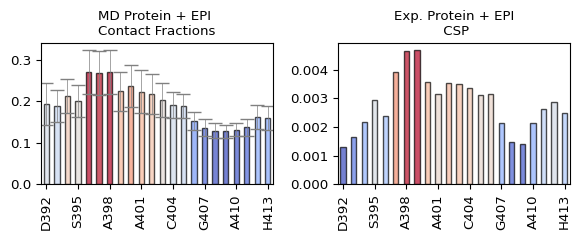

In [473]:
#index=0 # first ligand trajectory (1aa is second one, e.i (index = 1))
# protein-ligand computations



# ca_distances = ca_distances = ResidueDistances(index_0=np.arange(24),
#                                 index_1=np.arange(24, 48),
#                                 traj=md.load(protein_files[1], top=protein_pdb, atom_indices=ca_selection)
#                                )
# dimer = ca_distances.contacts(1).any(1)
cut = .6
fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))
scale = 1.6
window = 3
key = 'monomer_ligand' # not forcibly bound
where = apo_epi_csp != 0.0
mu, err = (i[where] for i in monomer_aggr_stats(ligand_distances.contacts(cut)))
box_plot(window_average(mu, window),
         ax=axes[0],
         labels=xticks[1:-1],
         errors=window_average(err, 3),
         font_scale=scale, 
         width=.5,
         #color_list='indianred',
         alpha=.7, 
         color_height=True,
         cmap='coolwarm', 
         title='MD Protein + EPI \nContact Fractions',
        label_stride=3, rotation=90)

box_plot(window_average(apo_epi_csp, window), ax=axes[1],
         font_scale=scale, width=.5, color_height=True, cmap='coolwarm',
         alpha=.7, title='Exp. Protein + EPI\n CSP',
         label_stride=3,
         labels=xticks[1:-1], rotation=90
        )

print(corr(window_average(apo_epi_csp[where], window),
     window_average(mu, window))
     )
fig.tight_layout()


# PRE

In [ ]:
def compute_pre(traj,
                tag_idx,
                periodic: bool = True,
                #fill_zeros: bool = False,
                print_pairs: bool = False,
                ):

    """
    function to compute PREs for labeled residues (tag_idx), uses 0 indexing, fills zeros

    want output as tuple of (array(type_index), array(numerical results))
    """

    tag_idx = np.atleast_1d(tag_idx)

    sequence, residue_indices = get_residues(traj, slice_sequence=True)
    print(sequence, residue_indices)
    
    # remove proline
    bools = np.array([num_str(i, reverse=True) for i in sequence]) != 'PRO'
    residue_indices = residue_indices[bools]
    # get all the indices
    res_seq = np.array([traj.top.residue(i).resSeq for i in residue_indices])
    h_indices = np.array([traj.top.select(f'resid {i} and name H').item() for i in residue_indices])
    ca_indices = np.array([traj.top.select(f'resid {i} and name CA').item() for i in residue_indices])

    tag_idx = np.where(np.isin(residue_indices, tag_idx))[0]
    print(tag_idx)
    pairs = np.concatenate([product([ca_indices[i]], h_indices) for i in tag_idx])

    if print_pairs:
        print(np.array([(traj.top.atom(i), traj.top.atom(j)) for i, j in pairs]))

    d = md.compute_distances(traj.center_coordinates() if not periodic else traj,
                             pairs,
                             periodic=periodic).astype(np.float64)

    b=18.8; k=1.23e-32; tdelay=0.010; R2exp=4.0; tc=4.0e-9; wH=2.6752e8*b*2.0*np.pi


    b      = 18.79          # if you want to keep b
    k      = 1.23e-32       # leave as is
    tdelay = 0.001          # change this
    wH     = 2.6752e8 * b   # or 2*np.pi*800e6
    R2exp  = 4.0        # change this from a single constant
    tc     = 4.0e-9         # cannot be set from the paper
    # calculate PRE
    d = k*np.power(d,-6)*(4.0*tc+3.0*tc/(1.0+(wH*tc)**2))*1.0e42
    # calculate Iratios

    
    d = (R2exp*np.exp(-tdelay * d) / (d + R2exp)).reshape(traj.n_frames,
                                                          len(tag_idx),
                                                          len(residue_indices))#.transpose(1, 2, 0)

    d[:, np.arange(len(tag_idx)), tag_idx] = 0
    ids = np.array(list(chain(*[[f'PRE{res_seq[i]}_{j}' for j in res_seq] for i in tag_idx])))

    return [d.reshape(-1, d.shape[1] * d.shape[2]), ids]

In [161]:
selections = ['residue 1 to 24', 'residue 27 to 50']
pre_selections = ['residue 14 or ' +selections[1], 'residue 40 or ' + selections[0]]
pre_indices = [0, 24]
pre = []
for i in range(2):
    pres = []
    for selection, index in zip(pre_selections, pre_indices):
        traj = md.load(protein_files[i], top=protein_pdb, atom_indices = md.load(protein_pdb).top.select(selection))
        pres.append(np.delete(compute_pre(traj, index)[0], index, axis=1))
        
    pre.append(np.add.reduce(pres) / 2)

    

['CYS14' 'LEU27' 'ASP28' 'TYR29' 'GLY30' 'SER31' 'ALA32' 'TRP33' 'ALA34'
 'ALA35' 'ALA36' 'ALA37' 'ALA38' 'GLN39' 'CYS40' 'ARG41' 'TYR42' 'GLY43'
 'ASP44' 'LEU45' 'ALA46' 'SER47' 'LEU48' 'HIS49' 'GLY50'] [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]
[0]
['LEU1' 'ASP2' 'TYR3' 'GLY4' 'SER5' 'ALA6' 'TRP7' 'ALA8' 'ALA9' 'ALA10'
 'ALA11' 'ALA12' 'GLN13' 'CYS14' 'ARG15' 'TYR16' 'GLY17' 'ASP18' 'LEU19'
 'ALA20' 'SER21' 'LEU22' 'HIS23' 'GLY24' 'CYS40'] [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]
[24]
['CYS14' 'LEU27' 'ASP28' 'TYR29' 'GLY30' 'SER31' 'ALA32' 'TRP33' 'ALA34'
 'ALA35' 'ALA36' 'ALA37' 'ALA38' 'GLN39' 'CYS40' 'ARG41' 'TYR42' 'GLY43'
 'ASP44' 'LEU45' 'ALA46' 'SER47' 'LEU48' 'HIS49' 'GLY50'] [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]
[0]
['LEU1' 'ASP2' 'TYR3' 'GLY4' 'SER5' 'ALA6' 'TRP7' 'ALA8' 'ALA9' 'ALA10'
 'ALA11' 'ALA12' 'GLN13' 'CYS14' 'ARG15' 'TYR16' 'GLY17' 'ASP18' 'LEU19'
 'ALA

In [69]:
pre_apo = np.array([0.467090038,
0.497776036,
0.434082566,
0.313703607,
0.107844251,
0.55053555,
0.223225818,
0.458279628,
0.376079258,
0.258323925,
0.626027833,
0.415897366,
0.40647308,
0.490905635,
0.378071239,
0.646480947,
0.478596642,
0.567612596,
0.497430783,
0.594060863,
0.629796778,
0.602669635,
0.687790511,
0.619549653,])

pre_epi = np.array([0.309529437,
0.35602248,
0.294830971,
0.0,
0.019504151,
0.390488005,
0.07529154,
0.372141133,
0.274601553,
0.324455918,
0.682610913,
0.220899945,
0.53245747,
0.369589434,
0.441344294,
0.724095674,
0.342271083,
0.493510566,
0.411766532,
0.487627224,
0.565100398,
0.499586659,
0.56011586,
0.573349045])

pre_apo_smooth = np.array([0.398477349,
0.38381071,
0.369281493,
0.353154797,
0.343407507,
0.345403755,
0.356554156,
0.371967769,
0.389799939,
0.409450183,
0.428181992,
0.442981891,
0.45499914,
0.468834966,
0.486963036,
0.507080452,
0.525645046,
0.542432621,
0.560168885,
0.580558702,
0.602222532,
0.622465658,
0.640169407,
0.656118126])
                    
                    

pre_epi_smooth = np.array([0.30144394,
                            0.276953961,
                            0.258090907,
                            0.240982633,
                            0.231075699,
                            0.235344696,
                            0.255876007,
                            0.289860581,
                            0.331208077,
                            0.371393896,
                            0.40273512,
                            0.423745192,
                            0.439789156,
                            0.456193133,
                            0.471605834,
                            0.480271482,
                            0.480494506,
                            0.478389295,
                            0.482177186,
                            0.49490278,
                            0.513964485,
                            0.535893531,
                            0.559822557,
                            0.586349139,])

In [194]:
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d

#y_smooth = savgol_filter(y, window_length=11, polyorder=3)

In [329]:
d = 0.5 * (np.power(ca_distances.matrix(contacts=False,cut_off=1)[:, 13, :], -6).mean(0) + 
          np.power(ca_distances.matrix(contacts=False,cut_off=1)[:, :, 13], -6).mean(0))
d = ca_distances.matrix(contacts=False,cut_off=1)[:, 13, :].astype(np.float64)

Text(0.5, 1.0, 'PRE')

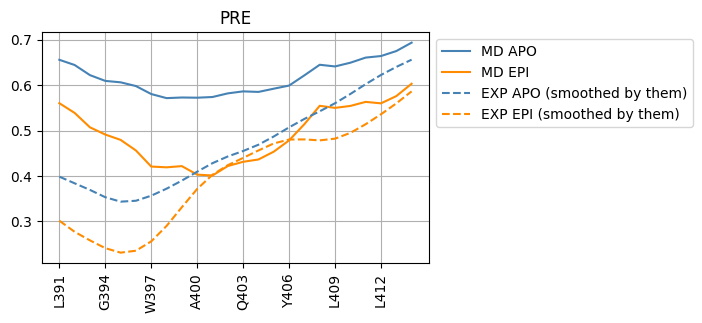

In [346]:
colors_exp = ["lightsteelblue", "orange"]
colors_sim = ["steelblue", "darkorange"]
plt.figure(figsize=(5, 3))
plt.plot(pre[0].mean(0),
         label='MD APO',
         color = colors_sim[0])
plt.plot(pre[1].mean(0),
         label='MD EPI',
         color = colors_sim[1])
#plt.plot(d.mean(0)*.6)
# plt.plot(gaussian_filter1d(pre_epi, 2.1, order=0))
# plt.plot(savgol_filter(pre_epi, window_length=16, polyorder=3, deriv=0))
plt.plot(pre_apo_smooth,
         label='EXP APO (smoothed by them)',
         color = colors_sim[0], ls='--')

plt.plot(pre_epi_smooth,
         label='EXP EPI (smoothed by them)',
         color = colors_sim[1], ls='--')

plt.xticks(np.arange(24)[::3], xticks[::3], rotation=90)
plt.grid()

plt.legend(ncol=1, bbox_to_anchor=[1, 1])
plt.title('PRE')

# comparing the gamma values form the main text - need to get the scaling right

0.6448329063427406

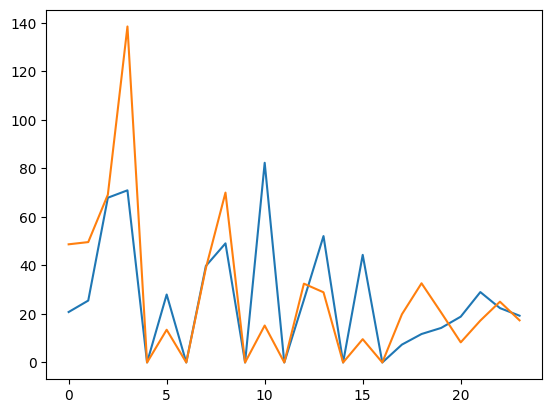

In [153]:
#plt.plot(np.power(ca_distances.matrix(contacts=False,cut_off=1)[:, 13, :], -6).mean(0) * 5e1)

gc = (1*np.power(ca_distances.matrix(contacts=False,cut_off=1)[:, :, 13], -6).mean(0) + 
      1*np.power(ca_distances.matrix(contacts=False,cut_off=1)[:, 13, :], -6).mean(0))*15
gc[where]=0
plt.plot(gc)
plt.plot(gamma_404)
corr(gamma_404, gc)

In [152]:
gamma_404_apo = np.array([48.72003148,
49.63511036,
69.18831913,
138.5317769,
0.0,
13.49040378,
0.0,
38.90640135,
70.03998836,
0.0,
15.2400812,
0.0,
32.49552476,
28.93963762,
0.0,
9.606575357,
0.0,
19.87258009,
32.64967819,
20.60424576,
8.294918065,
17.26913039,
25.06019961,
17.37853813])

gamma_404_epi = np.array([62.14071845,
36.25086007,
65.41415816,
0.0,
0.0,
0.0,
0.0,
64.09694727,
181.1015002,
0.0,
13.26561631,
0.0,
105.8099895,
93.32662643,
69.88777851,
17.10298122,
0.0,
34.04205152,
40.10231963,
26.3538417,
24.76910423,
44.98438937,
9.249910543,
45.44069282])

In [42]:
def csp(x, y, ):
    return np.linalg.norm((x - y) * np.array([1, 0.2]).reshape(2, 1), axis=0)

In [46]:
# taken from Fig_2I_1Tau5*_2Tau5*_CSPs_EPI001_1H_NMR


0.6147347114961805


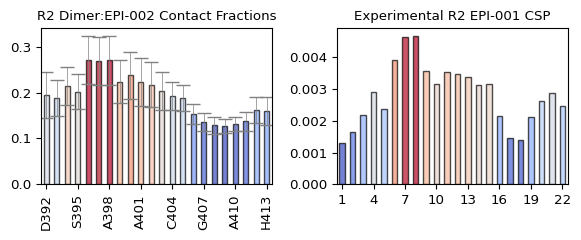

In [466]:
#index=0 # first ligand trajectory (1aa is second one, e.i (index = 1))
# protein-ligand computations



# ca_distances = ca_distances = ResidueDistances(index_0=np.arange(24),
#                                 index_1=np.arange(24, 48),
#                                 traj=md.load(protein_files[1], top=protein_pdb, atom_indices=ca_selection)
#                                )
# dimer = ca_distances.contacts(1).any(1)
cut = .6
fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))
scale = 1.6
window = 3
key = 'monomer_ligand' # not forcibly bound
where = apo_epi_csp != 0.0
mu, err = (i[where] for i in monomer_aggr_stats(ligand_distances.contacts(cut)))
box_plot(window_average(mu, window),
         ax=axes[0],
         labels=xticks[1:-1],
         errors=window_average(err, 3),
         font_scale=scale, 
         width=.5,
         #color_list='indianred',
         alpha=.7, 
         color_height=True,
         cmap='coolwarm', 
         title='R2 Dimer:EPI-002 Contact Fractions',
        label_stride=3, rotation=90)

box_plot(window_average(apo_epi_csp, window), ax=axes[1],
         font_scale=scale, width=.5, color_height=True, cmap='coolwarm',
         alpha=.7, title='Experimental R2 EPI-001 CSP', label_stride=3,
        )

print(corr(window_average(apo_epi_csp[where], window),
     window_average(mu, window))
     )
fig.tight_layout()


In [169]:
helix_monomer_dimer = np.array([
    [0.016, 0.02, 0.019, 0.02], # tau*, err, 2tau*, err
    [0.033, 0.02, 0.04, 0.02],
    [0.053, 0.02, 0.067, 0.02],
    [0.079, 0.02, 0.115, 0.02],
    [0.15,  0.02, 0.219, 0.02],
    [0.272, 0.02, 0.379, 0.02],
    [0.337, 0.02, 0.447, 0.02],
    [0.34,  0.02, 0.461, 0.02],
    [0.304, 0.02, 0.437, 0.02],
    [0.251, 0.02, 0.388, 0.02],
    [0.181, 0.02, 0.294, 0.02],
    [0.108, 0.02, 0.179, 0.02],
    [0.045, 0.02, 0.076, 0.02],
    [0.019, 0.02, 0.029, 0.02],
    [0.019, 0.02, 0.025, 0.02],
    [0.027, 0.02, 0.033, 0.02],
    [0.033, 0.02, 0.042, 0.02],
    [0.046, 0.02, 0.06,  0.02],
    [0.064, 0.02, 0.086, 0.02],
    [0.055, 0.02, 0.076, 0.02],
    [0.04,  0.02, 0.051, 0.02],
    [0.041, 0.02, 0.044, 0.02],
    [0.047, 0.02, 0.047, 0.02],
    [0.045, 0.02, 0.045, 0.02],
])


In [180]:

dssp_apo = np.where(md.compute_dssp(traj=md.load(protein_files[0], top=protein_pdb)) == 'H', 1, 0)[:, ca_index].reshape(-1, 2, 24
                                                                                                                   ).transpose(1, 0, 2)
dssp_epi = np.where(md.compute_dssp(traj=md.load(protein_files[1], top=protein_pdb)) == 'H', 1, 0)[:, ca_index].reshape(-1, 2, 24
                                                                                                                   ).transpose(1, 0, 2)

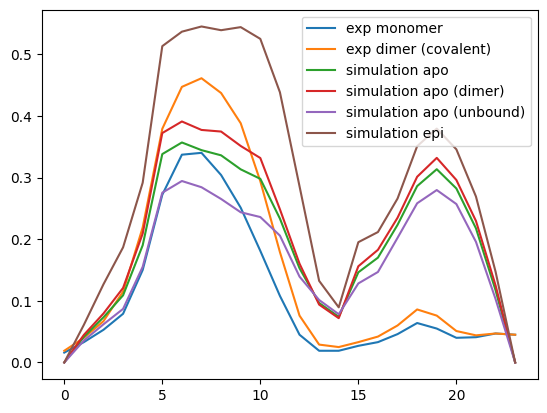

In [184]:
plt.plot(helix_monomer_dimer.T[0], label='exp monomer')
plt.plot(helix_monomer_dimer.T[2], label='exp dimer (covalent)')
plt.plot(dssp_apo.mean((0, 1)),label='simulation apo')
plt.plot(dssp_apo[:, dimer].mean((0, 1)),label='simulation apo (dimer)')
plt.plot(dssp_apo[:, ~dimer].mean((0, 1)),label='simulation apo (unbound)')
plt.plot(dssp_epi.mean((0, 1)), label='simulation epi')
plt.legend()

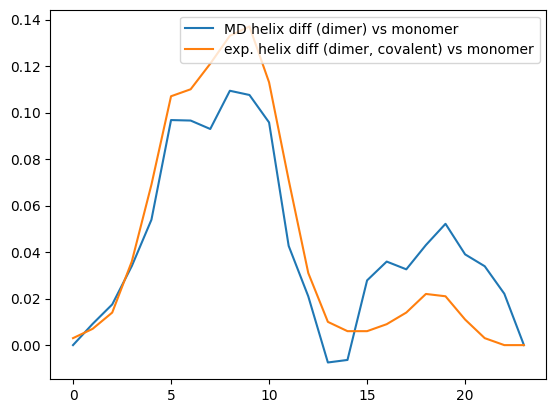

In [189]:
plt.plot(dssp_apo[:, dimer].mean((0, 1)) - dssp_apo[:, ~dimer].mean((0, 1)), label='MD helix diff (dimer) vs monomer')
plt.plot(helix_monomer_dimer.T[2] - helix_monomer_dimer.T[0], label='exp. helix diff (dimer, covalent) vs monomer')
plt.legend()

In [444]:


csp_matrix_apo = np.array([
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.032113485743035144, 0.10175878807590559, 0.028209276328557922, 0.034930607, 0.068700958, 0.16209937258939805, 0.080045639, 0.057767598, 0.068495171, 0.1125143958402493, 0.13503158907227994, 0.1512043447630363, 0.088991276, 0.057445979, 0.09327166, 0.0, 0.0, 0.044035896, 0.037056873999109036, 0.040079437, 0.068650715, 0.053502644],
    [0.0, 0.0, 0.10175878807590559, 0.32244556176598965, 0.089387424, 0.11068546985024835, 0.2176944056502887, 0.5136482484197252, 0.25364257594109063, 0.18304960202943432, 0.21704232320702424, 0.3565271192735483, 0.42787790045305224, 0.4791249071501064, 0.28198883438919575, 0.18203047880700257, 0.2955521921154751, 0.0, 0.0, 0.13953762132218897, 0.11742302340532147, 0.12700069138664757, 0.2175352001718991, 0.1695351371151123],
    [0.0, 0.0, 0.028209276328557922, 0.089387424, 0.024779723, 0.030683905180089628, 0.060348612245552456, 0.14239207884967572, 0.07031406, 0.05074448, 0.060167844, 0.098835415, 0.1186150715529336, 0.13282161823320954, 0.078172127, 0.050461962, 0.081932122, 0.0, 0.0, 0.038682214996223305, 0.032551670250873896, 0.035206764, 0.060304477764218406, 0.046998039],
    [0.0, 0.0, 0.034930607, 0.11068546985024835, 0.030683905180089628, 0.037994858, 0.074727676, 0.17631936815230512, 0.087067558, 0.0628352, 0.074503837, 0.12238460189998673, 0.14687709203004826, 0.16446858556345548, 0.096797942, 0.062485366, 0.10145381772478379, 0.0, 0.0, 0.047898898, 0.040307649, 0.043595363, 0.074673026, 0.058196107],
    [0.0, 0.0, 0.068700958, 0.2176944056502887, 0.060348612245552456, 0.074727676, 0.14697319445762969, 0.34678210343671745, 0.17124307593098947, 0.12358326193132514, 0.14653295053197607, 0.24070407079999417, 0.28887550729453193, 0.3234741744406098, 0.1903806377925111, 0.12289521579114379, 0.19953774041372038, 0.0, 0.0, 0.094206784, 0.079276437, 0.08574266, 0.14686570920708233, 0.11445916857711069],
    [0.0, 0.0, 0.16209937258939805, 0.5136482484197252, 0.14239207884967572, 0.17631936815230512, 0.34678210343671745, 0.8182296622712577, 0.40404669905600815, 0.2915937404794632, 0.34574335133551437, 0.5679393734744353, 0.6815995013282928, 0.7632347860024832, 0.44920162667039026, 0.28997030099014603, 0.4708077387242743, 0.0, 0.0, 0.22228017153733726, 0.18705213359414727, 0.20230913497946681, 0.34652849282826076, 0.2700655135330208],
    [0.0, 0.0, 0.080045639, 0.25364257594109063, 0.07031406, 0.087067558, 0.17124307593098947, 0.40404669905600815, 0.1995206756070093, 0.14399073235634277, 0.17073013393318465, 0.28045185807527995, 0.3365779087322046, 0.37688990036490244, 0.22181844882395685, 0.14318906823070476, 0.23248767612937318, 0.0, 0.0, 0.10976327761812459, 0.092367462, 0.09990146, 0.171117841, 0.1333599651826211],
    [0.0, 0.0, 0.057767598, 0.18304960202943432, 0.05074448, 0.0628352, 0.12358326193132514, 0.2915937404794632, 0.14399073235634277, 0.10391570167571926, 0.12321308027623833, 0.20239741225865213, 0.24290264367776557, 0.2719951333672452, 0.1600826621057583, 0.10333715409310289, 0.16778246488915072, 0.0, 0.0, 0.07921432, 0.066660051, 0.072097212, 0.12349288233577262, 0.096243655],
    [0.0, 0.0, 0.068495171, 0.21704232320702424, 0.060167844, 0.074503837, 0.14653295053197607, 0.34574335133551437, 0.17073013393318465, 0.12321308027623833, 0.14609402531423238, 0.23998306514014686, 0.288010209, 0.32250523897636535, 0.189810371, 0.12252709511142668, 0.1989400444972646, 0.0, 0.0, 0.093924597, 0.079038972, 0.085485826, 0.14642578724305463, 0.11411631725726705],
    [0.0, 0.0, 0.1125143958402493, 0.3565271192735483, 0.098835415, 0.12238460189998673, 0.24070407079999417, 0.5679393734744353, 0.28045185807527995, 0.20239741225865213, 0.23998306514014686, 0.3942109982265607, 0.4731033493339004, 0.5297670155013784, 0.31179423354894464, 0.20127057067743018, 0.3267911987152274, 0.0, 0.0, 0.15428634181787215, 0.129834295, 0.14042429487272995, 0.24052803776585369, 0.1874545077322643],
    [0.0, 0.0, 0.13503158907227994, 0.42787790045305224, 0.1186150715529336, 0.14687709203004826, 0.28887550729453193, 0.6815995013282928, 0.3365779087322046, 0.24290264367776557, 0.288010209, 0.4731033493339004, 0.5677842073353748, 0.6357878154791662, 0.3741927466727469, 0.2415502904236881, 0.39219101278386764, 0.0, 0.0, 0.18516323846591315, 0.15581767180899053, 0.16852701860428107, 0.288664245, 0.22496925721210492],
    [0.0, 0.0, 0.1512043447630363, 0.4791249071501064, 0.13282161823320954, 0.16446858556345548, 0.3234741744406098, 0.7632347860024832, 0.37688990036490244, 0.2719951333672452, 0.32250523897636535, 0.5297670155013784, 0.6357878154791662, 0.7119362269845676, 0.4190098736485099, 0.2704808085409152, 0.43916379505978836, 0.0, 0.0, 0.2073402700715734, 0.17447998005688023, 0.18871152741369498, 0.32323761, 0.25191386224726264],
    [0.0, 0.0, 0.088991276, 0.28198883438919575, 0.078172127, 0.096797942, 0.1903806377925111, 0.44920162667039026, 0.22181844882395685, 0.1600826621057583, 0.189810371, 0.31179423354894464, 0.3741927466727469, 0.4190098736485099, 0.24660814769683856, 0.15919140663919662, 0.2584697326871538, 0.0, 0.0, 0.12203005981717108, 0.10269014502532493, 0.1110661183692562, 0.19024140757010216, 0.14826383542471663],
    [0.0, 0.0, 0.057445979, 0.18203047880700257, 0.050461962, 0.062485366, 0.12289521579114379, 0.28997030099014603, 0.14318906823070476, 0.10333715409310289, 0.12252709511142668, 0.20127057067743018, 0.2415502904236881, 0.2704808085409152, 0.15919140663919662, 0.10276182755696892, 0.16684834099928897, 0.0, 0.0, 0.078773297, 0.066288923, 0.071695813, 0.12280533938130508, 0.095707821],
    [0.0, 0.0, 0.09327166, 0.2955521921154751, 0.081932122, 0.10145381772478379, 0.19953774041372038, 0.4708077387242743, 0.23248767612937318, 0.16778246488915072, 0.1989400444972646, 0.3267911987152274, 0.39219101278386764, 0.43916379505978836, 0.2584697326871538, 0.16684834099928897, 0.2709018470772333, 0.0, 0.0, 0.1278995736163422, 0.10762942985537478, 0.11640827845149679, 0.19939181336830805, 0.15539516543674173],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.044035896, 0.13953762132218897, 0.038682214996223305, 0.047898898, 0.094206784, 0.22228017153733726, 0.10976327761812459, 0.07921432, 0.093924597, 0.15428634181787215, 0.18516323846591315, 0.2073402700715734, 0.12203005981717108, 0.078773297, 0.1278995736163422, 0.0, 0.0, 0.060384604637185944, 0.05081456, 0.054959275, 0.094137889, 0.073365965],
    [0.0, 0.0, 0.037056873999109036, 0.11742302340532147, 0.032551670250873896, 0.040307649, 0.079276437, 0.18705213359414727, 0.092367462, 0.066660051, 0.079038972, 0.129834295, 0.15581767180899053, 0.17447998005688023, 0.10269014502532493, 0.066288923, 0.10762942985537478, 0.0, 0.0, 0.05081456, 0.042761223, 0.046249063176776135, 0.07921846, 0.061738572],
    [0.0, 0.0, 0.040079437, 0.12700069138664757, 0.035206764, 0.043595363, 0.08574266, 0.20230913497946681, 0.09990146, 0.072097212, 0.085485826, 0.14042429487272995, 0.16852701860428107, 0.18871152741369498, 0.1110661183692562, 0.071695813, 0.11640827845149679, 0.0, 0.0, 0.054959275, 0.046249063176776135, 0.050021391, 0.085679954, 0.066774309],
    [0.0, 0.0, 0.068650715, 0.2175352001718991, 0.060304477764218406, 0.074673026, 0.14686570920708233, 0.34652849282826076, 0.171117841, 0.12349288233577262, 0.14642578724305463, 0.24052803776585369, 0.288664245, 0.32323761, 0.19024140757010216, 0.12280533938130508, 0.19939181336830805, 0.0, 0.0, 0.094137889, 0.07921846, 0.085679954, 0.1467583025632437, 0.11437546166404162],
    [0.0, 0.0, 0.053502644, 0.1695351371151123, 0.046998039, 0.058196107, 0.11445916857711069, 0.2700655135330208, 0.1333599651826211, 0.096243655, 0.11411631725726705, 0.1874545077322643, 0.22496925721210492, 0.25191386224726264, 0.14826383542471663, 0.095707821, 0.15539516543674173, 0.0, 0.0, 0.073365965, 0.061738572, 0.066774309, 0.11437546166404162, 0.089138032],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
])
csp_matrix_apo = csp_matrix_apo[1:24, 1:24]



import numpy as np

csp_matrix_epi = np.array([
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.054952978037945494, 0.077743675, 0.027767084229696093, 0.055251322, 0.088979337, 0.080422829, 0.14420450596131906, 0.11342541286487895, 0.053657209, 0.18424000863841342, 0.049564676, 0.15334146444147695, 0.0610765, 0.021024612942947093, 0.11594657934295088, 0.0, 0.0, 0.024079967591773485, 0.038477163, 0.05070916, 0.054183543256999325, 0.032272651633612676],
    [0.0, 0.0, 0.077743675, 0.051648675, 0.026872456573170805, 0.075428629, 0.10858240992211757, -0.005434228, 0.20838614824451354, 0.16928653247730233, 0.037445754, 0.2556289522079219, -0.039732808, 0.15314351778818536, 0.031204719422880722, -0.017027607, 0.13760767667025364, 0.0, 0.0, 0.00303295, 0.039343085447841264, 0.060920938, 0.038347838, 0.009777253],
    [0.0, 0.0, 0.027767084229696093, 0.026872456573170805, 0.011390224745814519, 0.027335551154307386, 0.041280001434369294, 0.015276319441026448, 0.073795658, 0.059188855, 0.018929531933475012, 0.092026118, 0.001674713, 0.063910501, 0.019117787503962466, 0.000673473, 0.052964777700350824, 0.0, 0.0, 0.005565349, 0.016231502878796215, 0.023321176, 0.01922898, 0.008674068],
    [0.0, 0.0, 0.055251322, 0.075428629, 0.027335551154307386, 0.055422863507296166, 0.088650749, 0.075266247, 0.1451926988930866, 0.1144550342173331, 0.052143807, 0.1850046795594918, 0.044679598, 0.1511808723315916, 0.058818086, 0.018944292, 0.11533621394971763, 0.0, 0.0, 0.022754642, 0.037977975114471964, 0.050476858, 0.052680386, 0.030764430464647115],
    [0.0, 0.0, 0.088979337, 0.10858240992211757, 0.041280001434369294, 0.088650749, 0.13894454313116922, 0.094869197, 0.23479208849943273, 0.18627284799524996, 0.075474939, 0.2968307161162544, 0.047678805, 0.22937180537878993, 0.082524911, 0.020173195692647194, 0.17990339267044891, 0.0, 0.0, 0.029787343, 0.057826563, 0.078899568, 0.076373868, 0.041615789],
    [0.0, 0.0, 0.080422829, -0.005434228, 0.015276319441026448, 0.075266247, 0.094869197, -0.125905381, 0.21998238923019825, 0.18401986823173078, -7.48e-05, 0.25937201049734926, -0.151944312, 0.094053478, -0.023418877, -0.064807162, 0.11568644808536255, 0.0, 0.0, -0.028175582, 0.02547132, 0.052104104, 0.001017267, -0.026088621],
    [0.0, 0.0, 0.14420450596131906, 0.20838614824451354, 0.073795658, 0.1451926988930866, 0.23479208849943273, 0.21998238923019825, 0.3780851446188521, 0.2969830260948883, 0.14368924650117385, 0.4838488432469511, 0.13830431805505755, 0.407174805, 0.1644139040128221, 0.058679691, 0.3062425046045161, 0.0, 0.0, 0.065516957, 0.10210154729437365, 0.13387958107390469, 0.14505861247928437, 0.087379219],
    [0.0, 0.0, 0.11342541286487895, 0.16928653247730233, 0.059188855, 0.1144550342173331, 0.18627284799524996, 0.18401986823173078, 0.2969830260948883, 0.23278162835215904, 0.11656638877218253, 0.38103878457795115, 0.11891250615117038, 0.326148611, 0.13441066184394626, 0.050467187178070125, 0.24331422894032997, 0.0, 0.0, 0.054394134, 0.081700317, 0.10630169214046892, 0.11762895917330547, 0.072036891],
    [0.0, 0.0, 0.053657209, 0.037445754, 0.018929531933475012, 0.052143807, 0.075474939, -7.48e-05, 0.14368924650117385, 0.11656638877218253, 0.027030392897091415, 0.17658507533362716, -0.024035545, 0.10766379194804526, 0.023239038, -0.010309944, 0.095789027, 0.0, 0.0, 0.003050196, 0.027619198559151736, 0.042380071146054396, 0.027648139048653625, 0.007854415],
    [0.0, 0.0, 0.18424000863841342, 0.2556289522079219, 0.092026118, 0.1850046795594918, 0.2968307161162544, 0.25937201049734926, 0.4838488432469511, 0.38103878457795115, 0.17658507533362716, 0.617266498, 0.15671973615247514, 0.5086149395265143, 0.20001905014945104, 0.066463291, 0.3864578998767741, 0.0, 0.0, 0.078061493, 0.127702861, 0.16908065378790735, 0.17836326050414927, 0.10511187622797899],
    [0.0, 0.0, 0.049564676, -0.039732808, 0.001674713, 0.044679598, 0.047678805, -0.151944312, 0.13830431805505755, 0.11891250615117038, -0.024035545, 0.15671973615247514, -0.162156168, 0.018179005066040976, -0.048861169, -0.069111048, 0.054816776258743705, 0.0, 0.0, -0.036719558, 0.006285678, 0.025364367, -0.023264307, -0.038455771],
    [0.0, 0.0, 0.15334146444147695, 0.15314351778818536, 0.063910501, 0.1511808723315916, 0.22937180537878993, 0.094053478, 0.407174805, 0.326148611, 0.10766379194804526, 0.5086149395265143, 0.018179005066040976, 0.35812662373458704, 0.11006407912587907, 0.007521512, 0.2946419400010871, 0.0, 0.0, 0.03325707, 0.090864038, 0.12966881614116563, 0.1093046701339696, 0.050818689999455297],
    [0.0, 0.0, 0.0610765, 0.031204719422880722, 0.019117787503962466, 0.058818086, 0.082524911, -0.023418877, 0.1644139040128221, 0.13441066184394626, 0.023239038, 0.20001905014945104, -0.048861169, 0.11006407912587907, 0.015647361577990626, -0.020890397, 0.10386156709405925, 0.0, 0.0, -0.002602435, 0.028484177261507093, 0.046122416, 0.023973022246447706, 0.001917513],
    [0.0, 0.0, 0.021024612942947093, -0.017027607, 0.000673473, 0.018944292, 0.020173195692647194, -0.064807162, 0.058679691, 0.050467187178070125, -0.010309944, 0.066463291, -0.069111048, 0.007521512, -0.020890397, -0.029455024, 0.023173872870309725, 0.0, 0.0, -0.015668213, 0.002621402, 0.010727013327764351, -0.009982327, -0.016419104],
    [0.0, 0.0, 0.11594657934295088, 0.13760767667025364, 0.052964777700350824, 0.11533621394971763, 0.17990339267044891, 0.11568644808536255, 0.3062425046045161, 0.24331422894032997, 0.095789027, 0.3864578998767741, 0.054816776258743705, 0.2946419400010871, 0.10386156709405925, 0.023173872870309725, 0.23266830397113664, 0.0, 0.0, 0.036749384, 0.074347684, 0.10209176627789036, 0.096970879, 0.051840139],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.024079967591773485, 0.00303295, 0.005565349, 0.022754642, 0.029787343, -0.028175582, 0.065516957, 0.054394134, 0.003050196, 0.078061493, -0.036719558, 0.03325707, -0.002602435, -0.015668213, 0.036749384, 0.0, 0.0, -0.005957258, 0.008832086, 0.016465076, 0.003364597, -0.004945273],
    [0.0, 0.0, 0.038477163, 0.039343085447841264, 0.016231502878796215, 0.037977975114471964, 0.057826563, 0.02547132, 0.10210154729437365, 0.081700317, 0.027619198559151736, 0.127702861, 0.006285678, 0.090864038, 0.028484177261507093, 0.002621402, 0.074347684, 0.0, 0.0, 0.008832086, 0.023036892756214754, 0.032706909, 0.028028464, 0.013314789],
    [0.0, 0.0, 0.05070916, 0.060920938, 0.023321176, 0.050476858, 0.078899568, 0.052104104, 0.13387958107390469, 0.10630169214046892, 0.042380071146054396, 0.16908065378790735, 0.025364367, 0.12966881614116563, 0.046122416, 0.010727013327764351, 0.10209176627789036, 0.0, 0.0, 0.016465076, 0.032706909, 0.044786688505175705, 0.04289496, 0.023126340031398927],
    [0.0, 0.0, 0.054183543256999325, 0.038347838, 0.01922898, 0.052680386, 0.076373868, 0.001017267, 0.14505861247928437, 0.11762895917330547, 0.027648139048653625, 0.17836326050414927, -0.023264307, 0.1093046701339696, 0.023973022246447706, -0.009982327, 0.096970879, 0.0, 0.0, 0.003364597, 0.028028464, 0.04289496, 0.028270501357287814, 0.008260365],
    [0.0, 0.0, 0.032272651633612676, 0.009777253, 0.008674068, 0.030764430464647115, 0.041615789, -0.026088621, 0.087379219, 0.072036891, 0.007854415, 0.10511187622797899, -0.038455771, 0.050818689999455297, 0.001917513, -0.016419104, 0.051840139, 0.0, 0.0, -0.004945273, 0.013314789, 0.023126340031398927, 0.008260365, -0.003114451],
])
csp_matrix_epi = csp_matrix_epi[1:24, 1:24]

In [447]:
contact_epi_mean = ca_distances = ResidueDistances(index_0=np.arange(24),
                                index_1=np.arange(24, 48),
                                traj=md.load(protein_files[1], top=protein_pdb, atom_indices=ca_selection)
                               ).matrix(contacts=True, cut_off=.8).mean(0)



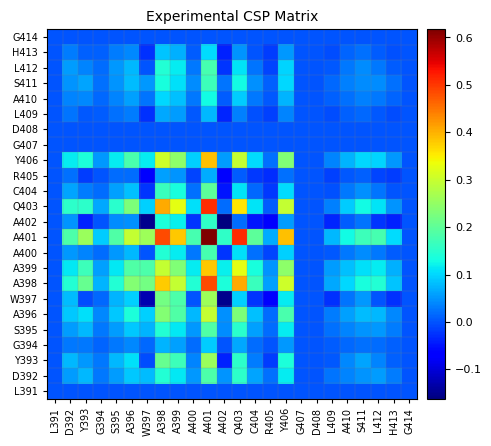

In [446]:
plot_distance_matrix(np.pad(csp_matrix_epi[::-1, ::-1], ((1, 0), (1, 0)),mode='constant', constant_values=0)[::-1, ::-1],
                     xticks=xticks, 
                     yticks=xticks,
                     xticks_rotation=90, grid=True,
                     #ax=axes[0],
                    title='Experimental CSP Matrix', label_stride=1)


In [455]:
contact_mean = ca_distances.matrix(contacts=True, cut_off=.8).mean(0)

AttributeError: 'numpy.ndarray' object has no attribute 'matrix'

Text(0.5, 1, '      APO')

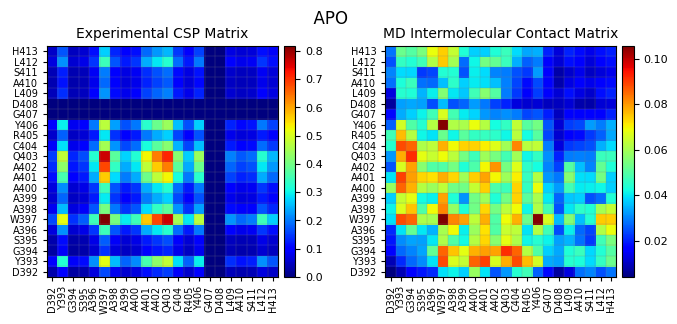

In [452]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

plot_distance_matrix(np.pad(csp_matrix[::-1, ::-1], ((1, 0), (1, 0)), mode='constant', constant_values=0)[::-1, ::-1][1:-1,1:-1],
                     xticks=xticks[1:-1], yticks=xticks[1:-1], xticks_rotation=90, grid=True, ax=axes[0],
                    title='Experimental CSP Matrix', label_stride=1)

plot_distance_matrix(((contact_mean.T + contact_mean) / 2)[1:-1,1:-1], 
                    xticks=xticks[1:-1], yticks=xticks[1:-1],
                     xticks_rotation=90,
                     grid=True, ax=axes[1], 
                    title='MD Intermolecular Contact Matrix', label_stride=1)
fig.suptitle('      APO', y=1)

Text(0.5, 1, '      EPI - APO')

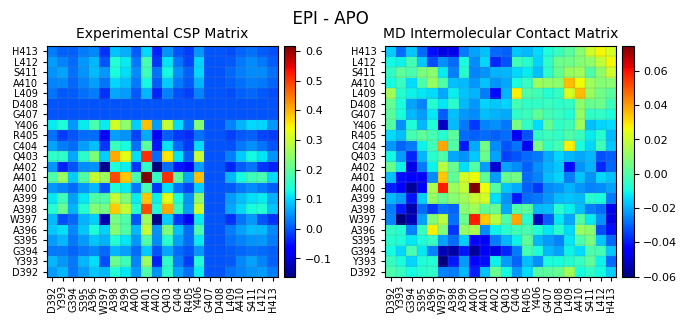

In [456]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
plot_distance_matrix(np.pad(csp_matrix_epi[::-1, ::-1], ((1, 0), (1, 0)), mode='constant', constant_values=0)[::-1, ::-1][1:-1,1:-1],
                     xticks=xticks[1:-1], yticks=xticks[1:-1], xticks_rotation=90, grid=True, ax=axes[0],
                    title='Experimental CSP Matrix', label_stride=1)
plot_distance_matrix(((contact_epi_mean.T + contact_epi_mean) / 2 - (contact_mean.T + contact_mean) / 2)[1:-1,1:-1], 
                        xticks=xticks[1:-1], yticks=xticks[1:-1],
                     xticks_rotation=90,
                     grid=True, ax=axes[1], 
                    title='MD Intermolecular Contact Matrix', label_stride=1)
fig.suptitle('      EPI - APO', y=1)

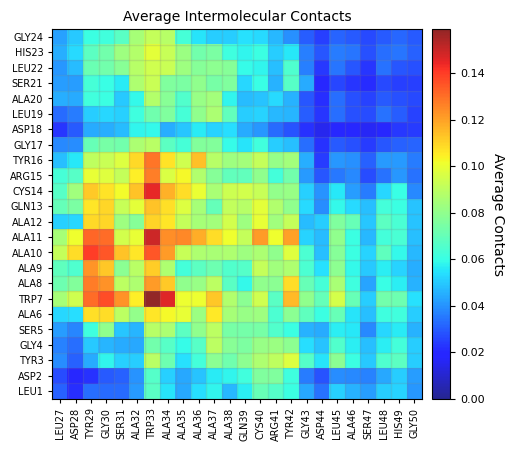

In [381]:
ca_distances.plot(contacts=True, grid_linewidth=True, contact_cutoff=1, label_stride=1,xticks_rotation=90 )

In [479]:
samples = [torch.load(i).numpy() for i in ['/home/t/Downloads/final_scripts/samples_base.pt', 
                                          '/home/t/Downloads/final_scripts/samples_ctrl.pt']]
samples.append(np.concatenate(load_dict('/home/t/Downloads/final_scripts/mb_simulations.pkl')))




In [480]:
def filt(x,
         xmin=-2.332331895828247,
         xmax=1.0913116931915283,
         ymin=-0.35450321435928345,
         ymax=2.432257652282715):
    """
    Keep only rows [x_i, y_i] with
        xmin <= x_i <= xmax
        ymin <= y_i <= ymax

    Works for either:
        - numpy array of shape (n, 2)
        - torch tensor of shape (n, 2)
    """
    mask = (
        (x[:, 0] >= xmin) &
        (x[:, 0] <= xmax) &
        (x[:, 1] >= ymin) &
        (x[:, 1] <= ymax)
    )
    return x[mask]

In [481]:
from writhe_tools.stats import DensityComparator, dKL, dJS

In [482]:
#del samples

In [483]:
dens = DensityComparator(samples[::-1])
dens.estimate_hist()
dens.estimate_kde()
print(dens.compare('kdes', metric=dJS),
      dens.compare('kdes', metric=dKL),
      
     )

[0.00672364 0.00803904 0.0012696 ] [0.03604413 0.04231737 0.00584477]


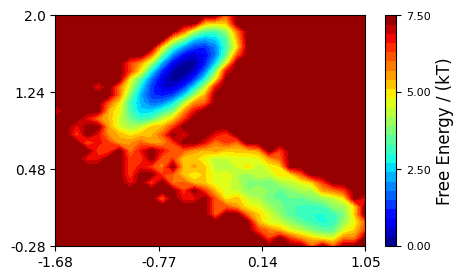

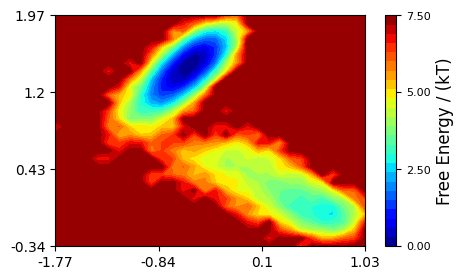

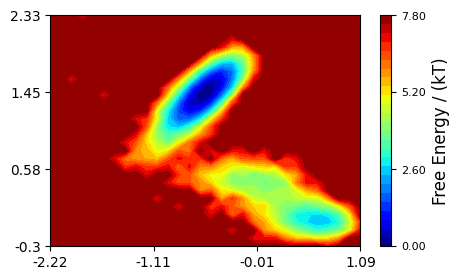

In [487]:
fes2d(filt(samples[1]), mask=False, bins=30, n_contours=25)
fes2d(filt(samples[0]), mask=False, bins=30, n_contours=25)
fes2d(filt(samples[2])[::5], mask=False, bins=30, n_contours=25)

In [27]:
from writhe_tools.msm_tools import MarkovModel
macrostates = load_dict('density_clusters.pkl')[0]
microstates = load_dict('msm_clusters.pkl')[0]

# msms = [MarkovModel(i).estimate_msm(lag, 10, reversible=False) for i, lag in zip(microstates, (150, 300, 150))]
# fig, axes = plt.subplots(1, 3, figsize=(16, 3), sharey=True)
# for model, ax, label in zip(msms, axes.flat, labels):
#     model.its('msm', ax=ax, n_its=5, cmap='coolwarm')

In [242]:
tcca = tCCA(writhe_features, lag=200, dim=10,).fit()
proj = tcca.transform()

In [258]:
msm = MarkovModel(Kmeans(proj, 250, 2)[0]).estimate_msm(100, 10, reversible=False)

In [245]:
msm_rev =  MarkovModel(msm.dtraj).estimate_msm(100, 10, reversible=True)

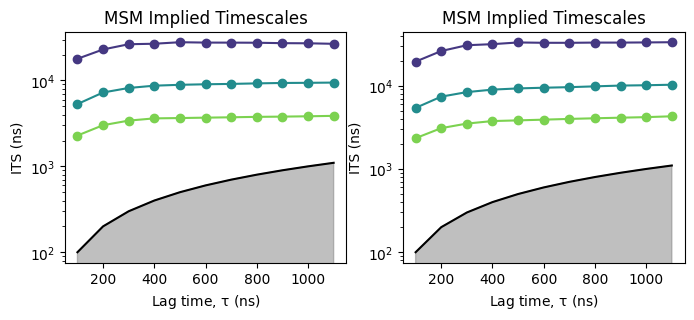

In [259]:
_,ax = plt.subplots(1, 2, figsize=(8, 3))
msm.its('msm', n_its=3, ax=ax[0])
msm_rev.its('msm', n_its=3, ax=ax[1])

In [253]:
msm_rev.estimate_hmm(4)

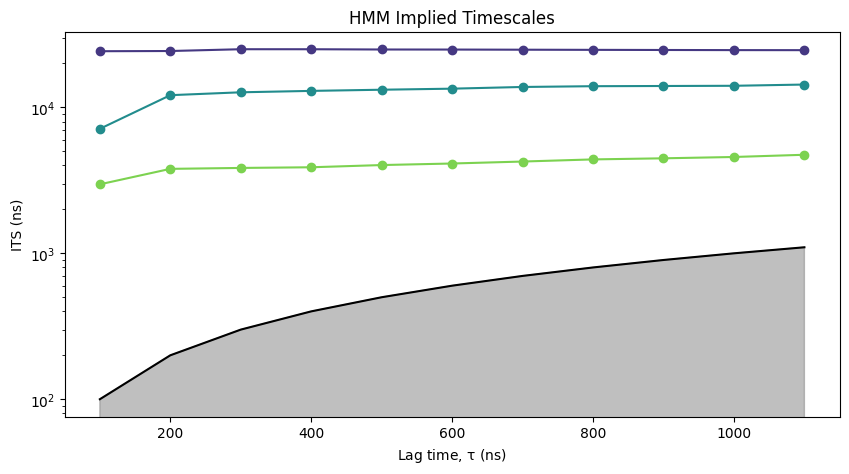

In [255]:
msm_rev.its('hmm')

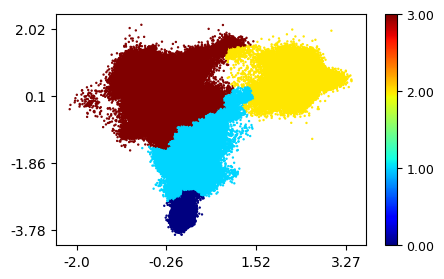

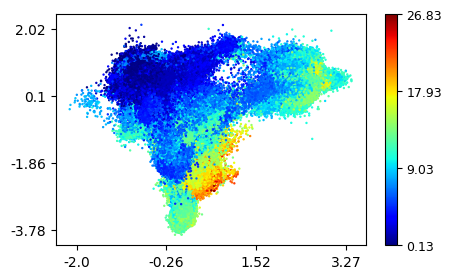

In [252]:
msm_rev.estimate_pcca(4)
pcca_macrostates = msm_rev.pcca['data']['dtrajs'][5]
proj2d(proj[:, :2], c=pcca_macrostates)
proj2d(proj[:, :2], c=sa.sum((0,2)))

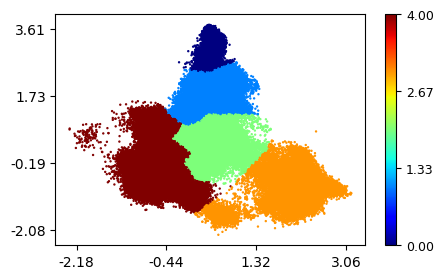

In [200]:
step = 3
hmm_macrostates = msm_rev.hmm['data']['dtrajs'][step]
proj2d(proj[:, :2], c=msm_rev.hmm['data']['dtrajs'][step])

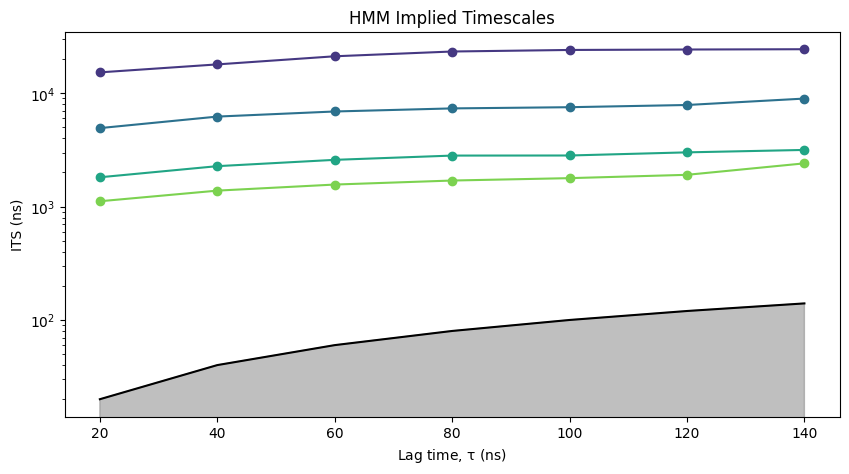

In [202]:
msm_rev.its('hmm', )

In [ ]:
msm = MarkovModel(Kmeans(proj, 55, 2)[0]).estimate_msm(100, 10, reversible=False)

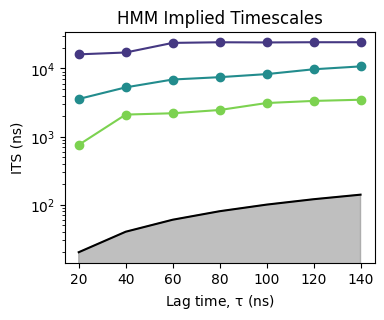

In [204]:
msm_rev =  MarkovModel(msm.dtraj).estimate_msm(20, 6, reversible=True)
msm_rev.estimate_hmm(4)
_,ax = plt.subplots(1, 1, figsize=(4, 3))
msm_rev.its('hmm', ax=ax)

<Axes: title={'center': 'MFPT Matrix : APO'}, xlabel='$State_{i}$', ylabel='$State_{j}$'>

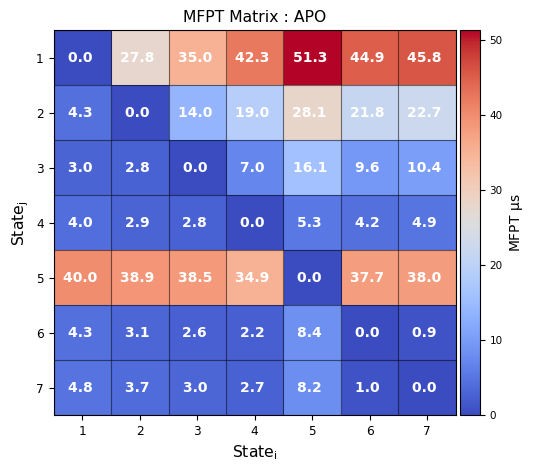

In [393]:
from writhe_tools.plots import annotated_matrix_plot
import deeptime
def mfpt_mat(tmat, states, dt=1, lag=1, mu=None):
    nstates = len(states)
    mfpt = np.zeros((nstates, nstates))
    for i, s0 in enumerate(states):
        for j, s1 in enumerate(states):
            mfpt[i, j] = deeptime.markov.tools.analysis.mfpt(tmat, s0, s1)
    return mfpt * dt * lag

mode =lambda x : np.bincount(x).argmax()
tmat = msm.msm['data']['tmats'][4]
sets = group_by(*group_by(msm.dtraj, macrostates, mode, return_keys=True))
annotated_matrix_plot(mfpt_mat(tmat, sets, lag=500) * 0.24e-3,
                      decimals=1,
                      cmap='coolwarm', 
                      title = f'MFPT Matrix : {label}',
                      font_scale=.25,
                      cbar_label=r'MFPT $\mu$s',
                      grid=True, grid_alpha=.3, 
                      figsize=(5.5,5)
                      )

In [388]:
from itertools import chain

In [391]:
survival_times = []
ids = set(range(7))
for i in range(7):
    survival_times.append(deeptime.markov.tools.analysis.mfpt(tmat, 
                                                              sets[i],
                                                              list(chain(*reindex_list(sets, list(ids - {i})))))
                         )

In [394]:
survival_times

[370.59384457968633,
 179.93747511395435,
 83.64940030557469,
 37.82078312323307,
 313.3947600103882,
 22.128336486469504,
 28.8037250800168]

In [265]:
mode =lambda x : np.bincount(x).argmax()
sets = group_by(*group_by(msm.dtraj, macrostates, mode, return_keys=True))
micro_centroids = group_by(msm.dtraj, proj, lambda x : x.mean(0))
bound_states = group_by(msm.dtraj, ca_distances.contacts(1).any(1), np.mean)
sa_states = group_by(msm.dtraj, sa.sum((0, 2)), 
                     np.mean)

In [272]:
vec = np.abs(msm.msm['msms'][4].eigenvectors_left())
vec_idx = 3
end_states = np.array([vec.T[vec_idx].argmin(), vec.T[vec_idx].argmax()])

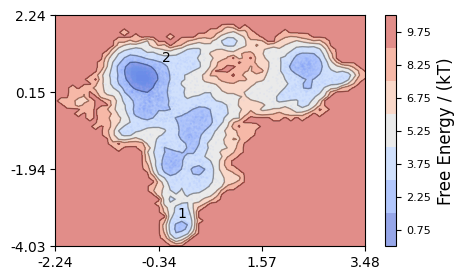

In [273]:
fes2d(proj[:, :2], cluster_centers=micro_centroids[end_states], **fes2d_args)

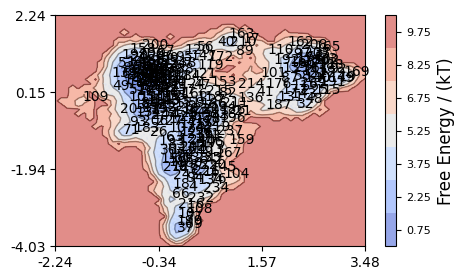

In [274]:
fes2d(proj[:, :2], cluster_centers=micro_centroids, **fes2d_args)

In [290]:
end_states

array([ 9, 49])

In [399]:
path = np.concatenate(reindex_list(msm.msm['msms'][0].reactive_flux( [9,], [49]).pathways()[0], [0])
                      #+reindex_list(msm.msm['msms'][0].reactive_flux( [13,], [40]).pathways()[0], [0, 1, 3, 4, 5])
                      #reindex_list(msm.msm['msms'][0].reactive_flux( [7,], [4]).pathways()[0], [0, 1, 3, 4, 5])
                     )
path = np.unique(path)

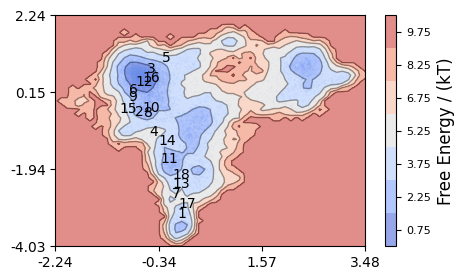

In [400]:
fes2d(proj[:, :2], cluster_centers=micro_centroids[path], **fes2d_args)

In [308]:
counts = group_by(macrostates, reduction=np.sum)
counts / counts.sum()

array([0.02463159, 0.03419095, 0.07057793, 0.12593481, 0.12589161,
       0.22691883, 0.39185427])

In [309]:
stationary_distribution = np.array([msm.msm['msms'][4].stationary_distribution[i].sum() for i in sets])

In [310]:
stationary_distribution * 100

array([ 2.54616534,  3.29390988,  7.07242295, 12.64287586, 12.67714374,
       20.88379257, 40.88368966])

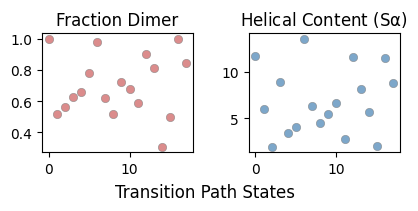

In [403]:
fig, axes = plt.subplots(1, 2, figsize=(4.2, 2.3))
s=None
axes[0].scatter(np.arange(len(path)),
                bound_states[path], alpha=.7,
                edgecolors='gray',
                color='indianred' ,s=s, linewidths=.5)
axes[0].set_title('Fraction Dimer')
axes[1].scatter(np.arange(len(path)), sa_states[path], alpha=.7, edgecolors='gray', color='steelblue', s=s, linewidths=.5)
axes[1].set_title(r'Helical Content (S$\alpha$)')
#fig.supxlabel('Transition Pathway State', y=-0.15)
fig.supxlabel('Transition Path States',
              y=0.1,
             )
#fig.suptitle(r'Slowest Process (~1.92$\mu$s)', y=1.2)
fig.tight_layout()

## survival_times = np.array(survival_times)

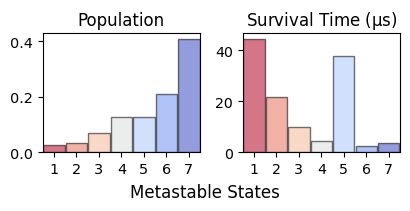

In [398]:
fig, axes = plt.subplots(1, 2, figsize=(4.2, 2.3))
box_plot(stationary_distribution, cmap='coolwarm_r', alpha=.55, ax=axes[0], font_scale=1.73, title='Population')
axes[0].set_title('Population')

box_plot(survival_times * 500 * 0.24e-3, 
         cmap='coolwarm_r', 
         alpha=.55,
         ax=axes[1],
         font_scale=1.7,
         title='Population')

axes[1].set_title(r'Survival Time ($\mu$s)')
fig.supxlabel('Metastable States',
              y=0.1,
             )
fig.tight_layout()

# box_plot(group_by(macrostates,(ca_distances.contacts(1).sum(-1) > 30), np.mean), 
#          cmap='coolwarm_r', 
#          alpha=.55,
#          ax=axes[1],
#          font_scale=1.7,
#          title='Population')

# axes[1].set_title('Fraction Dimer')
# fig.supxlabel('Metastable States',
#               y=0.1,
#              )
# fig.tight_layout()

 # Visualize latent space